# Gen 2 — relatório reprodutível

Lê todos os runs em `artifacts/runs/*__gen2__*`, monta a matriz pareada
`binary` × `mc8` (5 pares), e roda McNemar e plots.

Pré-requisitos: os runs precisam existir (veja `docs/relatorio_gen2.md`
para os comandos de reprodução). Dependências extras:
`uv sync --group report`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from ptbr_market.evaluation import mcnemar_test

RUNS_DIR = Path('../artifacts/runs')
assert RUNS_DIR.exists(), f'Rodar a partir de notebooks/; RUNS_DIR={RUNS_DIR.resolve()}'

## 1. Carregar metadata de todos os runs Gen 2

In [2]:
def load_runs(runs_dir: Path) -> pd.DataFrame:
    rows = []
    for d in sorted(runs_dir.iterdir()):
        meta_path = d / 'metadata.json'
        if not meta_path.exists():
            continue
        meta = json.loads(meta_path.read_text())
        if meta.get('generation') != 'gen2':
            continue
        target = meta['config'].get('target', {})
        mode = target.get('mode', 'binary')
        tag = f"mc{target.get('num_classes')}" if mode == 'multiclass' else 'bin'
        rows.append({
            'run_id': meta['run_id'],
            'model': meta['model'],
            'bucket': meta['config'].get('bucket'),
            'hf_id': meta['config'].get('hf_id'),
            'target_tag': tag,
            'threshold': meta['threshold']['value'],
            'pr_auc': meta['metrics']['pr_auc'],
            'roc_auc': meta['metrics']['roc_auc'],
            'f1_minority': meta['metrics']['f1_minority'],
            'precision_minority': meta['metrics']['precision_minority'],
            'recall_minority': meta['metrics']['recall_minority'],
            'latency_ms_per_1k': meta['efficiency']['latency_ms_per_1k'],
            'vram_peak_mb': meta['efficiency'].get('vram_peak_mb', 0.0),
            'run_dir': str(d),
        })
    return pd.DataFrame.from_records(rows)


summary = load_runs(RUNS_DIR).sort_values(['bucket', 'model', 'target_tag'])
print(f'{len(summary)} runs Gen 2 carregados')
summary[['bucket', 'model', 'target_tag', 'f1_minority', 'pr_auc', 'latency_ms_per_1k', 'vram_peak_mb']]

10 runs Gen 2 carregados


,bucket,model,target_tag,f1_minority,pr_auc,latency_ms_per_1k,vram_peak_mb
4,domain,deb3rta-base,bin,0.770249,0.844808,9293.937047,9186.659180
5,domain,deb3rta-base,mc8,0.790729,0.874311,9613.985845,9186.764648
2,domain,finbert-ptbr,bin,0.865465,0.940193,3956.351322,3101.578613
3,domain,finbert-ptbr,mc8,0.881410,0.946235,4033.659180,3101.631348
8,efficiency,distilbertimbau,bin,0.855017,0.927843,2699.076744,2564.017090
9,efficiency,distilbertimbau,mc8,0.870448,0.939188,2691.365498,2564.069824
6,multilingual,xlmr-base,bin,0.857785,0.933665,4198.761616,5029.602051
7,multilingual,xlmr-base,mc8,0.872923,0.943601,4203.020198,5029.654785
0,ptbr,bertimbau-base,bin,0.875427,0.942261,4115.715402,3099.203613
1,ptbr,bertimbau-base,mc8,0.883041,0.946439,4110.912523,3099.256348


## 2. Pareamento binary vs mc8

In [3]:
def pair(df: pd.DataFrame) -> pd.DataFrame:
    b = df[df.target_tag == 'bin'].set_index(['bucket', 'model'])
    m = df[df.target_tag == 'mc8'].set_index(['bucket', 'model'])
    cols = ['f1_minority', 'pr_auc', 'precision_minority', 'recall_minority',
            'latency_ms_per_1k', 'threshold', 'run_dir']
    out = b[cols].join(m[cols], lsuffix='_bin', rsuffix='_mc8', how='inner')
    out['delta_f1_minority'] = out.f1_minority_mc8 - out.f1_minority_bin
    out['delta_pr_auc'] = out.pr_auc_mc8 - out.pr_auc_bin
    return out.reset_index()

paired = pair(summary)
paired[['bucket', 'model', 'f1_minority_bin', 'f1_minority_mc8',
        'delta_f1_minority', 'pr_auc_bin', 'pr_auc_mc8', 'delta_pr_auc']]

,bucket,model,f1_minority_bin,f1_minority_mc8,delta_f1_minority,pr_auc_bin,pr_auc_mc8,delta_pr_auc
0,domain,deb3rta-base,0.770249,0.790729,0.020479,0.844808,0.874311,0.029504
1,domain,finbert-ptbr,0.865465,0.881410,0.015945,0.940193,0.946235,0.006041
2,efficiency,distilbertimbau,0.855017,0.870448,0.015431,0.927843,0.939188,0.011345
3,multilingual,xlmr-base,0.857785,0.872923,0.015138,0.933665,0.943601,0.009936
4,ptbr,bertimbau-base,0.875427,0.883041,0.007614,0.942261,0.946439,0.004177


## 3. F1-min e PR-AUC lado a lado

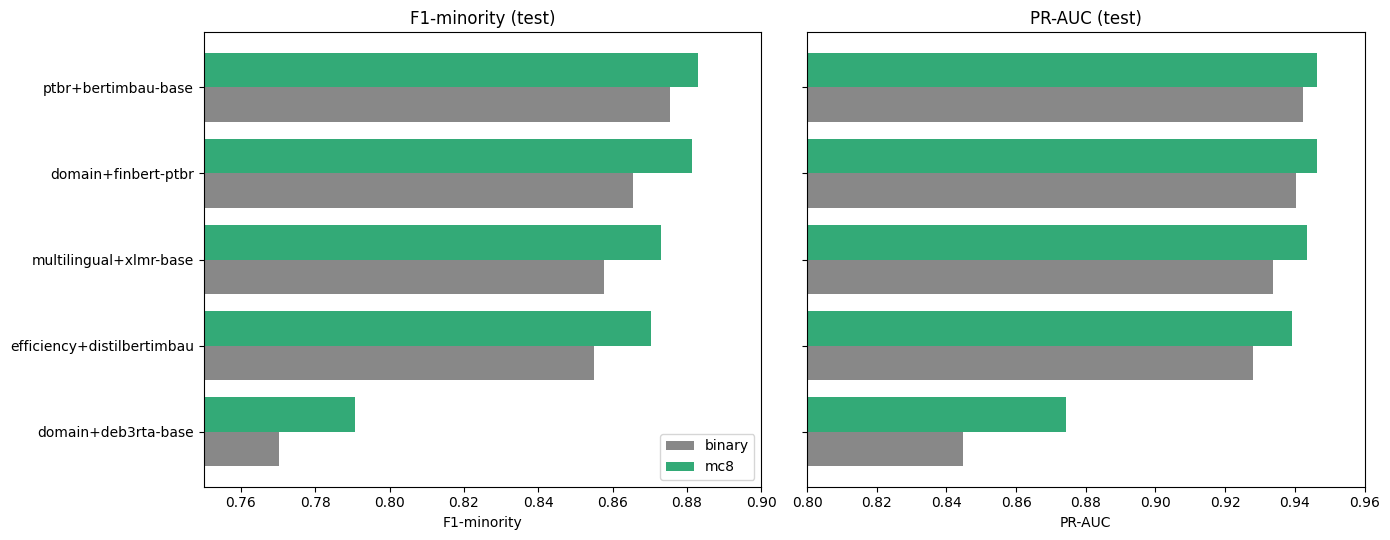

In [4]:
def _labels(df):
    return [f'{b}+{m}' for b, m in zip(df.bucket, df.model)]


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
order = paired.sort_values('f1_minority_mc8', ascending=True)
y = np.arange(len(order))

axes[0].barh(y - 0.2, order.f1_minority_bin, height=0.4, label='binary', color='#888')
axes[0].barh(y + 0.2, order.f1_minority_mc8, height=0.4, label='mc8', color='#3a7')
axes[0].set_yticks(y, _labels(order))
axes[0].set_xlabel('F1-minority')
axes[0].set_title('F1-minority (test)')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0.75, 0.90)

axes[1].barh(y - 0.2, order.pr_auc_bin, height=0.4, label='binary', color='#888')
axes[1].barh(y + 0.2, order.pr_auc_mc8, height=0.4, label='mc8', color='#3a7')
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC (test)')
axes[1].set_xlim(0.80, 0.96)

fig.tight_layout()
plt.show()

## 4. McNemar pareado (binary vs mc8)

`b` = binary acerta e mc8 erra; `c` = binary erra e mc8 acerta. χ² com
correção de continuidade; binomial exato quando `b+c < 25`
(ver `src/ptbr_market/evaluation.py`).

In [5]:
def mcnemar_rows(paired: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in paired.iterrows():
        pb = pd.read_csv(Path(r.run_dir_bin) / 'predictions.csv')
        pm = pd.read_csv(Path(r.run_dir_mc8) / 'predictions.csv')
        j = pb[['index', 'y_true', 'y_pred']].merge(
            pm[['index', 'y_true', 'y_pred']], on='index',
            suffixes=('_bin', '_mc8'),
        )
        assert (j.y_true_bin == j.y_true_mc8).all()
        res = mcnemar_test(j.y_true_bin.to_numpy(), j.y_pred_bin.to_numpy(),
                           j.y_pred_mc8.to_numpy())
        rows.append({
            'bucket': r.bucket,
            'model': r.model,
            'b_bin_only_correct': res['b'],
            'c_mc8_only_correct': res['c'],
            'statistic': res['statistic'],
            'p_value': res['p_value'],
            'winner': ('mc8' if res['c'] > res['b']
                       else 'binary' if res['b'] > res['c'] else 'tie'),
            'sig_0.05': res['p_value'] < 0.05,
        })
    return pd.DataFrame.from_records(rows)

mcnemar = mcnemar_rows(paired)
mcnemar.sort_values('p_value')

,bucket,model,b_bin_only_correct,c_mc8_only_correct,statistic,p_value,winner,sig_0.05
0,domain,deb3rta-base,261,363,16.347756,0.000053,mc8,True
3,multilingual,xlmr-base,216,283,8.729459,0.003131,mc8,True
1,domain,finbert-ptbr,172,229,7.820449,0.005166,mc8,True
2,efficiency,distilbertimbau,174,230,7.487624,0.006212,mc8,True
4,ptbr,bertimbau-base,174,201,1.802667,0.179390,mc8,False


In [6]:
n_sig = int(mcnemar['sig_0.05'].sum())
n_mc8_wins = int(((mcnemar.winner == 'mc8') & mcnemar['sig_0.05']).sum())
print(f'Pares: {len(mcnemar)} | p<0.05: {n_sig} | mc8 vence: {n_mc8_wins} |'
      f' empates (n.s.): {len(mcnemar) - n_sig}')

Pares: 5 | p<0.05: 4 | mc8 vence: 4 | empates (n.s.): 1


## 5. Curvas PR por modelo (mc8)

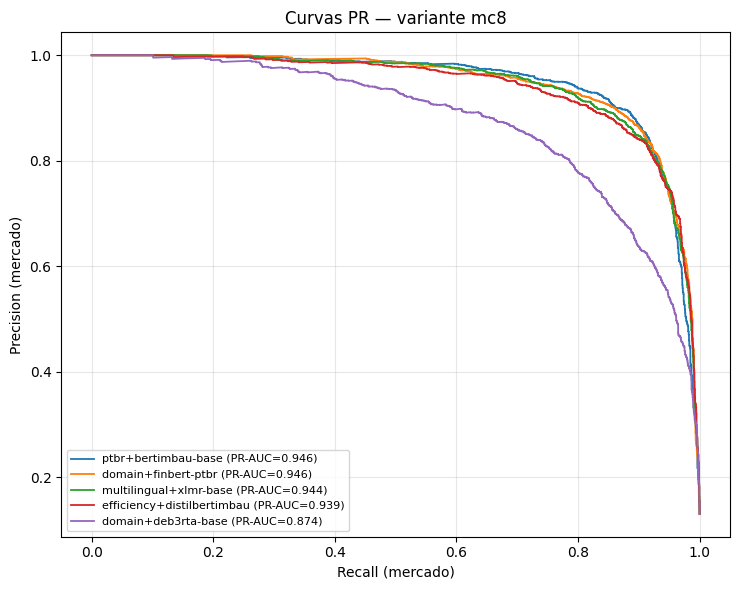

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for _, r in paired.sort_values('f1_minority_mc8', ascending=False).iterrows():
    pred = pd.read_csv(Path(r.run_dir_mc8) / 'predictions.csv')
    prec, rec, _ = precision_recall_curve(pred.y_true, pred.y_score)
    ax.plot(rec, prec,
            label=f'{r.bucket}+{r.model} (PR-AUC={r.pr_auc_mc8:.3f})',
            lw=1.3)
ax.set_xlabel('Recall (mercado)')
ax.set_ylabel('Precision (mercado)')
ax.set_title('Curvas PR — variante mc8')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Latência vs F1-min (trade-off Green-AI)

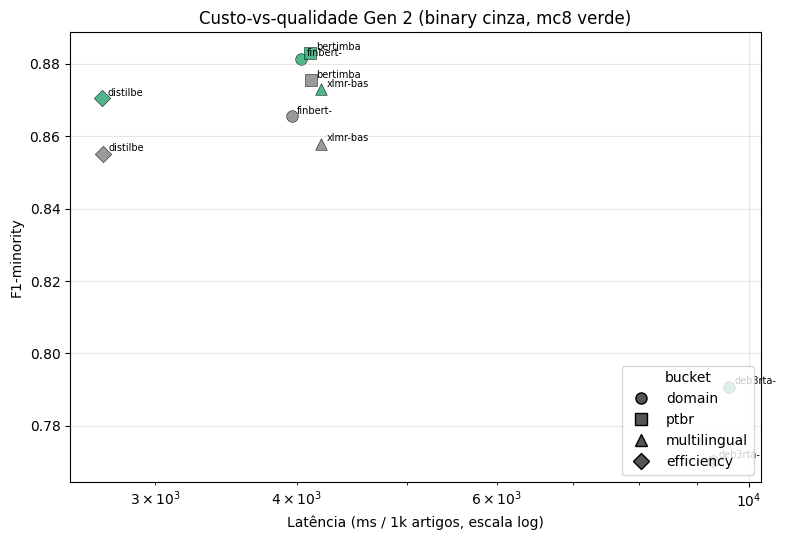

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = {'bin': '#888', 'mc8': '#3a7'}
markers = {'domain': 'o', 'ptbr': 's', 'multilingual': '^', 'efficiency': 'D'}
for _, r in summary.iterrows():
    ax.scatter(r.latency_ms_per_1k, r.f1_minority,
               color=colors[r.target_tag], marker=markers[r.bucket],
               s=70, alpha=0.85, edgecolors='black', linewidths=0.4)
    ax.annotate(r.model[:8], (r.latency_ms_per_1k, r.f1_minority),
                xytext=(4, 2), textcoords='offset points', fontsize=7)
ax.set_xscale('log')
ax.set_xlabel('Latência (ms / 1k artigos, escala log)')
ax.set_ylabel('F1-minority')
ax.set_title('Custo-vs-qualidade Gen 2 (binary cinza, mc8 verde)')
handles = [plt.Line2D([0], [0], marker=m, color='w', markerfacecolor='#555',
                      markeredgecolor='k', markersize=8, label=name)
           for name, m in markers.items()]
ax.legend(handles=handles, loc='lower right', title='bucket')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Campeão Gen 2

In [9]:
champ = summary.sort_values('f1_minority', ascending=False).iloc[0]
print(f'Campeão: {champ.bucket}+{champ.model} ({champ.target_tag})')
print(f'  HF id           : {champ.hf_id}')
print(f'  F1-min          : {champ.f1_minority:.4f}')
print(f'  PR-AUC          : {champ.pr_auc:.4f}')
print(f'  Precisão (min.) : {champ.precision_minority:.4f}')
print(f'  Recall (min.)   : {champ.recall_minority:.4f}')
print(f'  Threshold       : {champ.threshold:.2f}')
print(f'  Latência        : {champ.latency_ms_per_1k:.2f} ms / 1k')
print(f'  VRAM pico       : {champ.vram_peak_mb:.0f} MB')
print(f'  run_id          : {champ.run_id}')

Campeão: ptbr+bertimbau-base (mc8)
  HF id           : neuralmind/bert-base-portuguese-cased
  F1-min          : 0.8830
  PR-AUC          : 0.9464
  Precisão (min.) : 0.8651
  Recall (min.)   : 0.9017
  Threshold       : 0.16
  Latência        : 4110.91 ms / 1k
  VRAM pico       : 3099 MB
  run_id          : 20260422-155027__gen2__bertimbau-base__raw-ml256-mc8
